In [4]:
import pandas as pd
import numpy as np

In [5]:
df=pd.read_csv("housing.csv")

In [6]:
df["income_cat"]=pd.cut(df["median_income"],bins=[0,1.5,3.0,4.5,6.0,np.inf],labels=[1,2,3,4,5])

In [7]:
from sklearn.model_selection import StratifiedShuffleSplit
 
# Assume income_cat is a column in the dataset created from median_income
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [8]:
for train_index, test_index in split.split(df, df["income_cat"]):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [11]:
for sett in(strat_train_set,strat_test_set):
          sett.drop("income_cat",axis=1,inplace=True)  

In [14]:
df=strat_train_set.copy()

<Axes: xlabel='latitude', ylabel='longitude'>

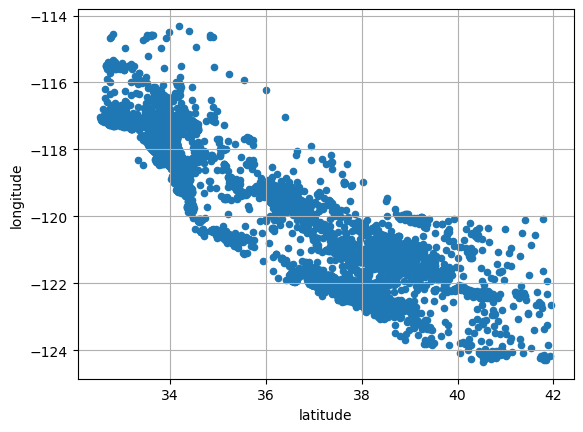

In [15]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True)

<Axes: xlabel='latitude', ylabel='longitude'>

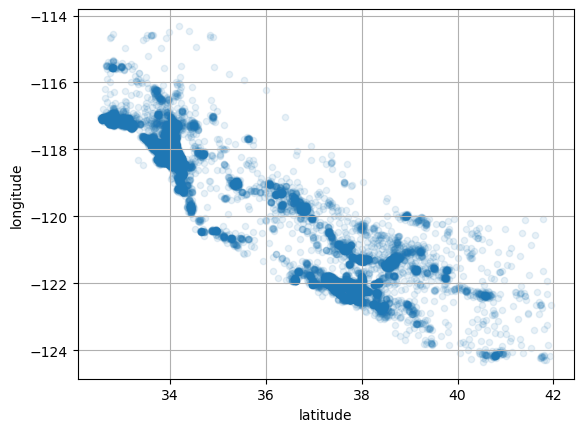

In [17]:
df.plot(kind="scatter",x="latitude",y="longitude",alpha=0.1,grid=True)

<Axes: xlabel='latitude', ylabel='longitude'>

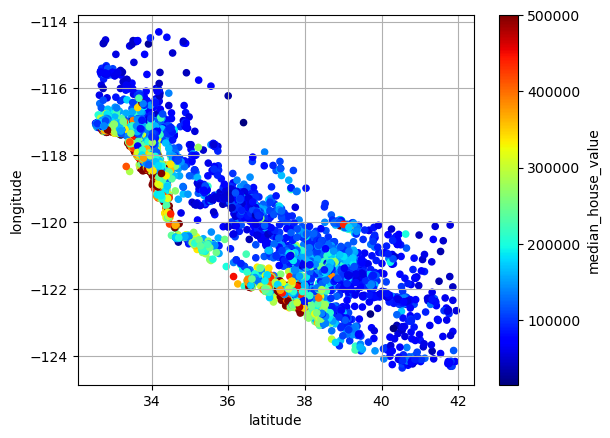

In [24]:
df.plot(kind="scatter",x="latitude",y="longitude",grid=True,cmap="jet",c="median_house_value")

In [18]:
df.drop(labels="ocean_proximity",inplace=True,axis=1)

In [28]:
cor=df.corr()

In [29]:
cor["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.687151
total_rooms           0.135140
housing_median_age    0.114146
households            0.064590
total_bedrooms        0.047781
population           -0.026882
longitude            -0.047466
latitude             -0.142673
Name: median_house_value, dtype: float64

array([[<Axes: xlabel='median_house_value', ylabel='median_house_value'>,
        <Axes: xlabel='median_income', ylabel='median_house_value'>,
        <Axes: xlabel='total_rooms', ylabel='median_house_value'>,
        <Axes: xlabel='housing_median_age', ylabel='median_house_value'>],
       [<Axes: xlabel='median_house_value', ylabel='median_income'>,
        <Axes: xlabel='median_income', ylabel='median_income'>,
        <Axes: xlabel='total_rooms', ylabel='median_income'>,
        <Axes: xlabel='housing_median_age', ylabel='median_income'>],
       [<Axes: xlabel='median_house_value', ylabel='total_rooms'>,
        <Axes: xlabel='median_income', ylabel='total_rooms'>,
        <Axes: xlabel='total_rooms', ylabel='total_rooms'>,
        <Axes: xlabel='housing_median_age', ylabel='total_rooms'>],
       [<Axes: xlabel='median_house_value', ylabel='housing_median_age'>,
        <Axes: xlabel='median_income', ylabel='housing_median_age'>,
        <Axes: xlabel='total_rooms', ylabel='housi

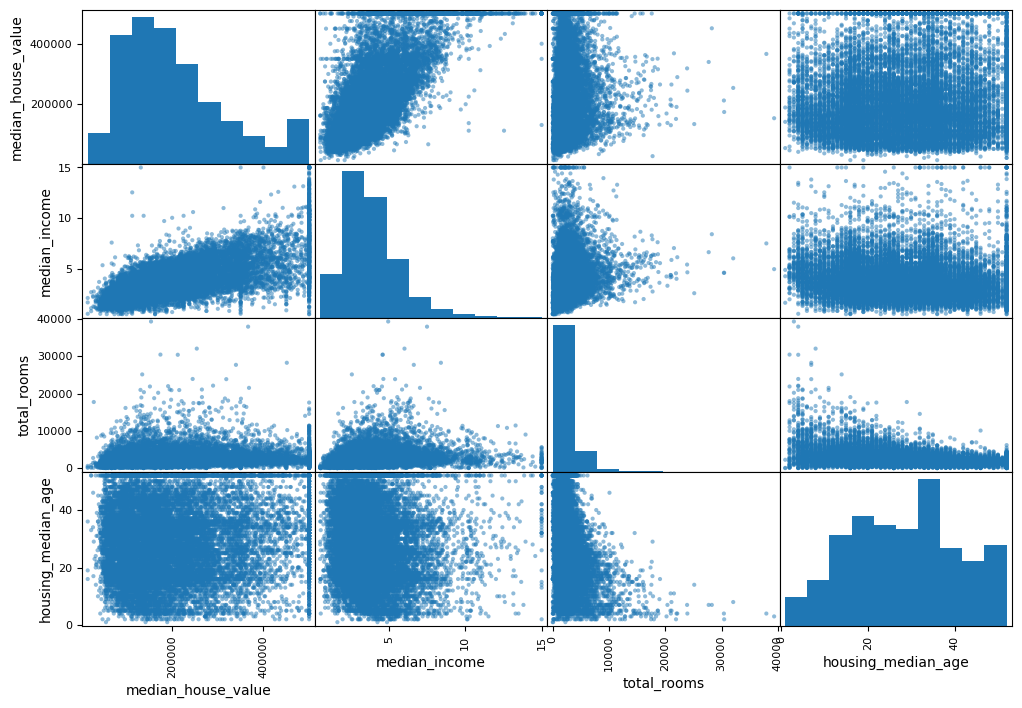

In [20]:
from pandas.plotting import scatter_matrix
attributes=["median_house_value","median_income","total_rooms","housing_median_age"]
scatter_matrix(df[attributes],figsize=(12,8))

<Axes: xlabel='median_income', ylabel='median_house_value'>

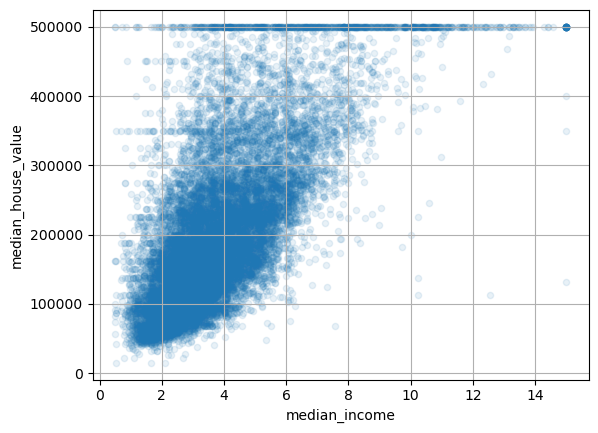

In [30]:
df.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.1, grid=True)